# Trump Tweet Event Study: Industry Intraday Volatility — SHORT-TERM (v5)

## Methodology: ΔRV = RV_post − RV_pre (Per-Bar Average)

$$RV_{pre} = \frac{1}{60}\sum_{m=-60}^{-1} r_m^2 \qquad
RV_{post} = \frac{1}{61}\sum_{m=0}^{+60} r_m^2 \qquad
\Delta RV = RV_{post} - RV_{pre}$$

| Parameter | Value |
|---|---|
| **Data** | Minute-level returns only (single CSV per event) |
| **Index column** | `t` — integer minute offset; t=0 = minute bar containing tweet |
| **Display window** | t ∈ [−60, +60] — 121 minute bars |
| **Pre window** | t ∈ [−60, −1] — 60 bars; **per-bar average** $RV_{pre} = \frac{1}{60}\sum r_t^2$ |
| **Post window** | t ∈ [0, +60] — 61 bars; **per-bar average** $RV_{post} = \frac{1}{61}\sum r_t^2$ |
| **Effect measure** | $\Delta RV = RV_{post} - RV_{pre}$ (per-bar averages, length-normalized) |
| **RV Proxy** | $r_t^2$ per bar |
| **Industries** | 10 sectors |
| **Column suffix** | `_minutely_return` |

### t Index Convention
| t | Meaning |
|---|---|
| t = 0 | 1-minute bar **containing** the tweet (ET) |
| t = −1 … −60 | 60 minutes before tweet |
| t = +1 … +60 | 60 minutes after tweet bar |

> **After-hours / weekend tweets:** t=0 assigned to next trading session open bar (09:30 ET).

---

## 0. Setup & Imports

In [ ]:
import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

# ── Global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'font.size'         : 10,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
PALETTE = plt.cm.tab10(np.linspace(0, 1, 10))

print("✅ Libraries loaded.")
print("   Time unit : trading MINUTE  (1-min bars, t = offset from tweet)")
print("   After-hours tweets → t=0 = next trading open bar (09:30 ET)")


---
## 1. Configuration

> **Edit only this cell** to update file paths or parameters.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# FILE PATHS
# ══════════════════════════════════════════════════════════════════
DATA_DIR = "MINUTELY EVENT STUDY PANELS BY SINGLE INDUSTRY"
PLOT_DIR = "plot_shortterm"    # output folder for figures

# ══════════════════════════════════════════════════════════════════
# WINDOW PARAMETERS  (t = minute offset from tweet bar)
# ══════════════════════════════════════════════════════════════════
PRE_T_START  = -60   # pre-event window start  (inclusive)
PRE_T_END    =  -1   # pre-event window end    (inclusive)
POST_T_START =   0   # post-event window start (t=0 = tweet bar)
POST_T_END   =  60   # post-event window end   (inclusive)
DISPLAY_WIN  =  60   # display range: ±DISPLAY_WIN minutes

# ── Derived ──────────────────────────────────────────────────────
T_MIN   = -DISPLAY_WIN          # -60
T_MAX   =  DISPLAY_WIN          # +60
T_VALS  = list(range(T_MIN, T_MAX + 1))   # 121 values
N_BARS  = len(T_VALS)           # 121

# ══════════════════════════════════════════════════════════════════
# INDUSTRY MAPPING  (CSV column name → display label)
# ══════════════════════════════════════════════════════════════════
IND_MAP = {
    'Airlines_&_Travel_minutely_return'             : 'Airlines & Travel',
    'Automobiles_&_Auto_Components_minutely_return' : 'Automobiles',
    'Chemicals_minutely_return'                     : 'Chemicals',        
    'Construction_&_Infrastructure_minutely_return' : 'Construction',
    'Defense_&_Aerospace_minutely_return'           : 'Defense & Aerospace',
    'Financials_(Banks)_minutely_return'            : 'Financials (Banks)',
    'News_&_Publishing_minutely_return'             : 'News & Publishing',
    'Oil_&_Natural_Gas_minutely_return'             : 'Oil & Gas',
    'Semiconductors_minutely_return'                : 'Semiconductors',   
    'Technology_&_Internet_minutely_return'         : 'Technology',
}
ALL_INDUSTRIES = list(IND_MAP.keys())
IND_LABELS     = list(IND_MAP.values())
N_IND          = len(ALL_INDUSTRIES)
IND_COLORS     = {col: PALETTE[i] for i, col in enumerate(ALL_INDUSTRIES)}

print(f"✅ Config set. {N_IND} industries | {N_BARS} minute bars per event.")
print(f"   Pre window  : t=[{PRE_T_START}, {PRE_T_END}]   ({abs(PRE_T_START)} bars)  → RV_pre  = mean(r²)")
print(f"   Post window : t=[{POST_T_START}, +{POST_T_END}]  ({POST_T_END - POST_T_START + 1} bars)  → RV_post = mean(r²)")
print(f"   ΔRV = RV_post − RV_pre  (per-bar averages, length-normalised)")
os.makedirs(PLOT_DIR, exist_ok=True)
print(f"   Data dir    : {DATA_DIR}")
print(f"   Plot dir    : {PLOT_DIR}")


---
## Step 1: Load Minute-Level Panels

**Goal:** Load all CSV files from `DATA_DIR`. Each CSV = one tweet event.

Expected CSV format:
- Index column: `t` (integer, −60 to +60)
- Return columns: `<Industry>_minutely_return`
- 121 rows per file

In [ ]:
def load_panels_and_build_mapping(data_dir, all_industries):
    """
    Load all minute-level panel CSVs and build a file_key -> [industries] mapping.
    Uses full filename as key to avoid collisions when the same tweet_id appears
    in multiple files (e.g. different industry subsets).

    Index column: 't' (integer minute offset, −60 to +60).
    Returns:
        panels : dict { file_key -> DataFrame indexed by t }
        mapping: dict { file_key -> [industry cols present] }
    """
    files   = sorted(glob.glob(os.path.join(data_dir, '*.csv')))
    panels  = {}
    mapping = {}

    for fpath in files:
        m = re.search(r'(\d{15,20})', os.path.basename(fpath))  
        if not m:
            continue

        try:
            df = pd.read_csv(fpath, index_col='t')
            df.index = df.index.astype(int)

            present_industries = [ind for ind in all_industries if ind in df.columns]
            if len(present_industries) == 0:
                continue

            # Full filename as key — preserves duplicate tweet_ids
            file_key = os.path.splitext(os.path.basename(fpath))[0]
            panels[file_key]  = df
            mapping[file_key] = present_industries
        except Exception as e:
            print(f"  ⚠️  Skipped {os.path.basename(fpath)}: {e}")

    return panels, mapping


panels, tweet_industry_map = load_panels_and_build_mapping(DATA_DIR, ALL_INDUSTRIES)

# ── Industry coverage ─────────────────────────────────────────────
industry_tweet_counts = {ind: 0 for ind in ALL_INDUSTRIES}
for inds in tweet_industry_map.values():
    for ind in inds:
        industry_tweet_counts[ind] += 1

print(f"✅ Loaded {len(panels)} panel CSVs.")
print(f"\n{'Industry':<45} {'# Tweets Mapped':>15}")
print("-" * 62)
for ind, label in IND_MAP.items():
    print(f"  {label:<43} {industry_tweet_counts[ind]:>15}")

# Distribution of industries per file
n_ind_per_tweet = pd.Series([len(v) for v in tweet_industry_map.values()])
print(f"\nIndustries per tweet:")
print(n_ind_per_tweet.value_counts().sort_index().to_string())

---
## Step 2: Verify Coverage

**Goal:** Confirm each panel covers t ∈ [−60, +60] (121 bars).

In [ ]:
coverage = []
for fk, df in panels.items():
    idx = df.index
    coverage.append({
        'file_key': fk,
        't_min'   : idx.min(),
        't_max'   : idx.max(),
        'n_rows'  : len(idx),
        'n_ind'   : len(tweet_industry_map[fk]),
    })
cov_df = pd.DataFrame(coverage)

print("Panel coverage summary:")
print(cov_df[['t_min','t_max','n_rows','n_ind']].describe().round(1))

short = cov_df[cov_df['n_rows'] < N_BARS]
if len(short):
    print(f"\n⚠️  {len(short)} panels have < {N_BARS} rows:")
    print(short[['file_key','t_min','t_max','n_rows']].head(10).to_string())
else:
    print(f"\n✅ All {len(panels)} panels have exactly {N_BARS} rows (t=[{T_MIN},{T_MAX}]).")

sample_fk  = list(panels.keys())[0]
sample_ind = tweet_industry_map[sample_fk][0]
print(f"\nSample: {sample_fk}")
print(f"  t range: {panels[sample_fk].index.min()} to {panels[sample_fk].index.max()}")
print(f"  Industry: {IND_MAP.get(sample_ind, sample_ind)}")
print(f"  Columns: {panels[sample_fk].columns.tolist()[:4]}")


---
## Step 3: Compute Per-Bar Realized Variance

$$RV_t = r_t^2$$

Squared minute-level returns proxy realized variance at each bar.
No log transformation applied.

In [ ]:
sample_fk  = list(panels.keys())[0]
sample_ind = tweet_industry_map[sample_fk][0]
r_t   = panels[sample_fk][sample_ind].dropna()
rv_t  = r_t ** 2

print(f"Sample: {sample_fk}")
print(f"Industry: {IND_MAP.get(sample_ind, sample_ind)}")

pre  = rv_t.loc[(rv_t.index >= PRE_T_START)  & (rv_t.index <= PRE_T_END)]
post = rv_t.loc[(rv_t.index >= POST_T_START) & (rv_t.index <= POST_T_END)]

print(f"\nPre window  t=[{PRE_T_START},{PRE_T_END}]:  N={len(pre)}  RV_pre={pre.sum():.8f}")
print(f"Post window t=[{POST_T_START},+{POST_T_END}]: N={len(post)}  RV_post={post.sum():.8f}")
print(f"ΔRV = {post.sum() - pre.sum():.8f}")
print(f"\nPer-bar RV_t (first 5 and last 5):")
print(pd.concat([rv_t.head(5), rv_t.tail(5)]).rename('RV_t').to_frame().to_string())
print("\n✅ RV_t = r_t²  (minute-level squared return)")


---
## Step 4: Compute RV_pre and RV_post

$$RV_{pre}  = \frac{1}{60}\sum_{t=-60}^{-1} r_t^2 \qquad (60 \text{ bars, per-bar avg})$$
$$RV_{post} = \frac{1}{61}\sum_{t=\;0}^{+60} r_t^2 \qquad (61 \text{ bars, per-bar avg})$$

Both are **per-bar averages** (divided by window length). This normalizes for the
asymmetric window sizes (pre=60 bars, post=61 bars), so $\Delta RV$ reflects
the change in per-minute realized variance rather than a sum inflated by bar count.

---
## Step 5: Compute ΔRV per Event

$$\Delta RV = RV_{post} - RV_{pre}$$

- $\Delta RV > 0$: the tweet **increased** cumulative realized variance
- $\Delta RV < 0$: the tweet **decreased** cumulative realized variance
- $\Delta RV = 0$: no change

This is a symmetric comparison: both windows span ~1 hour, and the difference
isolates the causal effect of the tweet on per-minute volatility.

In [ ]:
def compute_drv(panels, tweet_industry_map, ind_map,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                post_start=POST_T_START, post_end=POST_T_END):
    """
    Compute ΔRV = RV_post − RV_pre for every (event, industry) pair.

    RV_pre  = mean(r_t²)  for t ∈ [pre_start,  pre_end]   (60 bars, per-bar avg)
    RV_post = mean(r_t²)  for t ∈ [post_start, post_end]  (61 bars, per-bar avg)
    ΔRV     = RV_post − RV_pre
    """
    records = []
    for fk, df in panels.items():
        for ind in tweet_industry_map.get(fk, []):
            if ind not in df.columns:
                continue
            r_t   = df[ind].dropna()
            rv_t  = r_t ** 2

            pre  = rv_t.loc[(rv_t.index >= pre_start)  & (rv_t.index <= pre_end)]
            post = rv_t.loc[(rv_t.index >= post_start) & (rv_t.index <= post_end)]

            if len(pre) == 0 or len(post) == 0:
                continue

            rv_pre  = pre.mean()    # per-bar average: RV_pre / n_pre
            rv_post = post.mean()   # per-bar average: RV_post / n_post
            drv     = rv_post - rv_pre

            records.append({
                'file_key'      : fk,
                'industry'      : ind,
                'industry_label': ind_map[ind],
                'rv_pre'        : rv_pre,
                'rv_post'       : rv_post,
                'drv'           : drv,
                'n_pre'         : len(pre),
                'n_post'        : len(post),
            })
    return pd.DataFrame(records)


results = compute_drv(panels, tweet_industry_map, IND_MAP)

# Add year if timestamp available
year_map = {}
for fk, df in panels.items():
    if 0 in df.index and 'timestamp' in df.columns:
        try:
            year_map[fk] = pd.to_datetime(df.loc[0, 'timestamp']).year
        except:
            pass
results['year'] = results['file_key'].map(year_map)

print(f"Total (event × industry) pairs: {len(results)}")
print(f"\nΔRV summary by industry (×10⁴):")
tbl = results.groupby('industry_label')['drv'].agg(['count','mean','std','median'])
tbl.columns = ['N', 'Mean ΔRV', 'Std ΔRV', 'Median ΔRV']
tbl_d = tbl.copy()
for c in ['Mean ΔRV','Std ΔRV','Median ΔRV']:
    tbl_d[c] = (tbl_d[c] * 1e4).round(4)
print(tbl_d.to_string())


---
## Step 5.5: ★ Cross-Event Aggregation — Per-Bar AAV_t

**Goal:** For each minute t ∈ [−60, +60], compute the cross-event mean of
$(r_t^2 - RV_{pre,e})$ where $RV_{pre,e} = \frac{1}{60}\sum r_t^2$ is the
per-bar pre-event baseline for event e.

$$AAV_t^{(ind)} = \frac{1}{N_{ind}} \sum_{e=1}^{N_{ind}}
\left(r_{e,t}^2 - RV_{pre,e}\right)$$

where $RV_{pre,e} = \text{mean}(r_t^2,\; t \in [-60,-1])$ is the per-bar
pre-event average — identical to the baseline used in $\Delta RV$ computation.

In [ ]:
def compute_aav(panels, tweet_industry_map, ind_map,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                t_min=T_MIN, t_max=T_MAX):
    """
    Compute per-minute AAV_t across events for each industry.
    Per-bar baseline = mean(r_t², t∈pre) = RV_pre (consistent with compute_drv).
    Returns aav_df, se_df, n_df indexed by t in [t_min, t_max].
    """
    t_range = list(range(t_min, t_max + 1))

    aav_data = {ind: [] for ind in ind_map}
    se_data  = {ind: [] for ind in ind_map}
    n_data   = {ind: [] for ind in ind_map}

    for ind in ind_map:
        av_matrix = []
        for fk, df in panels.items():
            if ind not in tweet_industry_map.get(fk, []):
                continue
            if ind not in df.columns:
                continue
            r_t  = df[ind].dropna()
            rv_t = r_t ** 2

            # Per-bar baseline from pre window
            pre = rv_t.loc[(rv_t.index >= pre_start) & (rv_t.index <= pre_end)]
            if len(pre) == 0:
                continue
            baseline_per_bar = pre.mean()   # RV_pre = mean(r_t²) over pre window

            av_row = [rv_t.loc[t] - baseline_per_bar if t in rv_t.index else np.nan
                      for t in t_range]
            av_matrix.append(av_row)

        if not av_matrix:
            aav_data[ind] = [np.nan] * len(t_range)
            se_data[ind]  = [np.nan] * len(t_range)
            n_data[ind]   = [0]      * len(t_range)
        else:
            mat = np.array(av_matrix)
            cnt = np.sum(~np.isnan(mat), axis=0)
            aav_data[ind] = np.nanmean(mat, axis=0).tolist()
            se_data[ind]  = (np.nanstd(mat, axis=0, ddof=1)
                             / np.sqrt(np.maximum(cnt, 1))).tolist()
            n_data[ind]   = cnt.tolist()

    return (pd.DataFrame(aav_data, index=t_range),
            pd.DataFrame(se_data,  index=t_range),
            pd.DataFrame(n_data,   index=t_range))


aav_df, aav_se_df, aav_n_df = compute_aav(panels, tweet_industry_map, IND_MAP)

print("✅ Per-minute AAV series computed.")
print(f"   Shape: {aav_df.shape}  (rows = t bars, cols = industries)")
print(f"\nAAV_t matrix (×10⁴) — rows t=[-3,+3]:")
print((aav_df.rename(columns=IND_MAP).loc[-3:3] * 1e4).round(4).to_string())


---
## Step 6: Statistical Testing

**Goal:** Test whether mean $\Delta RV$ is statistically different from zero
for each industry across all events.

| Test | Null hypothesis | Notes |
|---|---|---|
| **Patell (1976)** | Mean standardized ΔRV = 0 | ΔRV standardized by RV_pre std |
| **Wilcoxon** | Median ΔRV = 0 | Distribution-free |
| **OLS HC3** | Mean ΔRV = 0 | Heteroskedasticity-robust SE |
| **BH FDR** | Patell p corrected for 10 tests | Controls false discovery rate |

In [ ]:
def patell_test(panels, tweet_industry_map, industry,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                post_start=POST_T_START, post_end=POST_T_END):
    """
    Patell (1976) test: standardize ΔRV by std of pre-window RV
    (cross-bar std of r_t² over the pre window) before pooling.
    """
    std_drvs = []
    for fk, df in panels.items():
        if industry not in tweet_industry_map.get(fk, []):
            continue
        if industry not in df.columns:
            continue
        r_t  = df[industry].dropna()
        rv_t = r_t ** 2

        pre  = rv_t.loc[(rv_t.index >= pre_start)  & (rv_t.index <= pre_end)]
        post = rv_t.loc[(rv_t.index >= post_start) & (rv_t.index <= post_end)]
        if len(pre) == 0 or len(post) == 0:
            continue

        rv_pre  = pre.mean()
        rv_post = post.mean()
        drv     = rv_post - rv_pre
        sig     = pre.std(ddof=1)        # cross-bar std of RV_pre
        if sig == 0:
            continue
        std_drvs.append(drv / sig)

    if len(std_drvs) < 2:
        return np.nan, np.nan, 0
    arr   = np.array(std_drvs)
    n     = len(arr)
    t_val = arr.mean() / (arr.std(ddof=1) / np.sqrt(n))
    p_val = 2 * stats.t.sf(abs(t_val), df=n - 1)
    return t_val, p_val, n


def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return 'n.s.'


def run_all_tests(panels, tweet_industry_map, results_df, industries, ind_map):
    rows = []
    for ind in industries:
        sub = results_df[results_df['industry'] == ind]['drv'].dropna()
        if len(sub) < 5:
            continue

        t_pat, p_pat, n = patell_test(panels, tweet_industry_map, ind)

        try:
            _, p_wil = stats.wilcoxon(sub, alternative='two-sided')
        except:
            p_wil = np.nan

        y = sub.values; X = np.ones((len(y), 1))
        model = sm.OLS(y, X).fit(cov_type='HC3')

        rows.append({
            'industry'    : ind,
            'label'       : ind_map[ind],
            'n_events'    : n,
            'mean_drv'    : sub.mean(),
            'median_drv'  : sub.median(),
            'pct_positive': (sub > 0).mean() * 100,
            't_patell'    : t_pat,
            'p_patell'    : p_pat,
            'sig_patell'  : sig_stars(p_pat),
            't_ols'       : model.tvalues[0],
            'p_ols'       : model.pvalues[0],
            'sig_ols'     : sig_stars(model.pvalues[0]),
            'p_wilcoxon'  : p_wil,
            'sig_wilcoxon': sig_stars(p_wil),
        })

    df_out = pd.DataFrame(rows)
    valid  = df_out['p_patell'].notna()
    if valid.sum() > 1:
        _, p_bh, _, _ = multipletests(df_out.loc[valid,'p_patell'], method='fdr_bh')
        df_out.loc[valid,'p_bh_adj'] = p_bh
        df_out.loc[valid,'sig_bh']   = df_out.loc[valid,'p_bh_adj'].apply(sig_stars)
    else:
        df_out['p_bh_adj'] = np.nan
        df_out['sig_bh']   = ''

    return df_out.set_index('label')


test_summary = run_all_tests(panels, tweet_industry_map, results, ALL_INDUSTRIES, IND_MAP)
print("✅ Statistical tests complete.")

disp = test_summary[['n_events','mean_drv','median_drv','pct_positive',
                      't_patell','p_patell','sig_patell',
                      'p_bh_adj','sig_bh','p_wilcoxon','sig_wilcoxon']].copy()
disp = disp.rename(columns={
    'n_events':'N', 'mean_drv':'Mean ΔRV (×10⁻⁴)', 'median_drv':'Median ΔRV (×10⁻⁴)',
    'pct_positive':'% Pos.', 't_patell':'t (Patell)', 'p_patell':'p (Patell)',
    'sig_patell':'Sig.', 'p_bh_adj':'p (BH adj.)', 'sig_bh':'Sig.(BH)',
    'p_wilcoxon':'p (Wilcox)', 'sig_wilcoxon':'Sig.(W)',
})
disp['Mean ΔRV (×10⁻⁴)']   *= 1e4
disp['Median ΔRV (×10⁻⁴)'] *= 1e4
print("=" * 85)
print("  TABLE 1: Short-Term Event Study — ΔRV by Industry")
print("  ΔRV = RV_post[t∈[0,+60]] − RV_pre[t∈[−60,−1]]  (cumulative squared returns)")
print("  Significance: * p<0.10  ** p<0.05  *** p<0.01  (Patell, two-tailed)")
print("=" * 85)
print(disp.to_string())


---
## Step 6.5: ★ Single-Sample t-Test — Mean ΔRV vs Zero (by Industry)

**Hypothesis:**
$$H_0: \mu_{\Delta RV} = 0 \qquad H_1: \mu_{\Delta RV} \neq 0$$

**Formula:**
$$t = \frac{\bar{\Delta RV}}{s / \sqrt{N}}, \quad df = N-1$$

- Each row is an **independent tweet event**.
- $\Delta RV$ = raw (unstandardized) realized variance change.
- BH (Benjamini-Hochberg) FDR correction applied across all industries.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 6.5 — Single-Sample t-Test: mean(ΔRV) = 0, by Industry
# ══════════════════════════════════════════════════════════════════

def one_sample_ttest_table(results_df, ind_map, min_n=2):
    """
    Perform a one-sample t-test (H0: mean(delta_rv) = 0) for each industry.
    Uses raw (unstandardized) ΔRV values from results_df['drv'].

    Parameters
    ----------
    results_df : DataFrame with columns ['industry', 'industry_label', 'drv']
    ind_map    : dict { industry_col -> display_label }
    min_n      : int, minimum events required to run test (default 2)

    Returns
    -------
    summary : DataFrame with N, Mean ΔRV, Std, Std Error, t-stat, p-value
    """
    rows = []
    for ind_col, label in ind_map.items():
        sub = results_df.loc[results_df['industry'] == ind_col, 'drv'].dropna()
        n   = len(sub)
        if n < min_n:
            rows.append({
                'Industry'    : label,
                'N'           : n,
                'Mean ΔRV'    : np.nan,
                'Std'         : np.nan,
                'Std Error'   : np.nan,
                't-stat'      : np.nan,
                'p-value'     : np.nan,
            })
            continue

        mean_drv = sub.mean()
        std_drv  = sub.std(ddof=1)
        se_drv   = std_drv / np.sqrt(n)
        t_stat   = mean_drv / se_drv          # t = mean / (std / sqrt(N))
        p_val    = 2 * stats.t.sf(abs(t_stat), df=n - 1)   # two-tailed

        rows.append({
            'Industry'    : label,
            'N'           : n,
            'Mean ΔRV'    : mean_drv,
            'Std'         : std_drv,
            'Std Error'   : se_drv,
            't-stat'      : t_stat,
            'p-value'     : p_val,
        })

    summary = pd.DataFrame(rows).set_index('Industry')

    # ── BH (Benjamini-Hochberg) FDR correction ────────────────────────
    valid_mask = summary['p-value'].notna()
    if valid_mask.sum() > 1:
        _, p_bh, _, _ = multipletests(
            summary.loc[valid_mask, 'p-value'], method='fdr_bh'
        )
        summary.loc[valid_mask, 'p-value (BH adj.)'] = p_bh
    else:
        summary['p-value (BH adj.)'] = np.nan

    return summary


ttest_summary = one_sample_ttest_table(results, IND_MAP)

# ── Significance stars ─────────────────────────────────────────────
def _stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return 'n.s.'

ttest_summary['Sig.']      = ttest_summary['p-value'].apply(_stars)
ttest_summary['Sig. (BH)'] = ttest_summary['p-value (BH adj.)'].apply(_stars)

# ── Display table (scaled ×10⁴ for readability) ────────────────────
display_cols = ['N', 'Mean ΔRV', 'Std', 'Std Error', 't-stat',
                'p-value', 'Sig.', 'p-value (BH adj.)', 'Sig. (BH)']

disp = ttest_summary[display_cols].copy()
for col in ['Mean ΔRV', 'Std', 'Std Error']:
    disp[col] = disp[col] * 1e4        # convert to ×10⁻⁴ for display

disp = disp.rename(columns={
    'Mean ΔRV'         : 'Mean ΔRV (×10⁻⁴)',
    'Std'              : 'Std (×10⁻⁴)',
    'Std Error'        : 'Std Error (×10⁻⁴)',
})

print('=' * 90)
print('  TABLE 2: Single-Sample t-Test — H₀: mean(ΔRV) = 0  |  Short-Term (1-min, ±60 bars)')
print('  ΔRV = mean(r²,t∈[0,+60]) − mean(r²,t∈[−60,−1])  (per-bar average squared returns)')
print('  Significance: * p<0.10  ** p<0.05  *** p<0.01  (two-tailed; BH FDR-corrected)')
print('=' * 90)
print(disp.round({'Mean ΔRV (×10⁻⁴)': 4,
                  'Std (×10⁻⁴)': 4,
                  'Std Error (×10⁻⁴)': 4,
                  't-stat': 3,
                  'p-value': 4,
                  'p-value (BH adj.)': 4}).to_string())
print('=' * 90)
print('\n  Notes:')
print('   • t = mean(ΔRV) / (std / √N)  with df = N−1  (standard one-sample t-test)')
print('   • BH correction controls FDR across all', len(IND_MAP), 'industries')
print('   • Industries with N < 2 are excluded from testing')


---
## Step 6.6: ★ Visualise Single-Sample t-Test Results

Three coordinated panels:
1. **Mean ΔRV ± 95% CI** — horizontal bar chart with 95% confidence intervals
2. **t-statistic** — diverging bar chart with significance threshold lines
3. **p-value comparison** — raw vs BH-adjusted, log-scale dot plot

In [ ]:
import gc
# ══════════════════════════════════════════════════════════════════
# Step 6.6 — Publication-quality plot of single-sample t-test results
# ══════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Reconstruct display data from ttest_summary ───────────────────
ts = ttest_summary.copy()
ts = ts[ts['N'] >= 2].copy()                        # drop rows with no test
ts = ts.sort_values('Mean ΔRV', ascending=True)     # sort by effect size

labels   = ts.index.tolist()
n_ind    = len(labels)

mean_drv = ts['Mean ΔRV'].values * 1e4              # ×10⁻⁴
se_drv   = ts['Std Error'].values * 1e4
t_stats  = ts['t-stat'].values
p_raw    = ts['p-value'].values
p_bh     = ts['p-value (BH adj.)'].values

ci95     = 1.96 * se_drv                            # approximate 95% CI half-width

# ── Significance colour mapping ───────────────────────────────────
def sig_color(p, palette):
    if pd.isna(p):      return palette[3]   # grey
    if p < 0.01:        return palette[0]   # dark
    if p < 0.05:        return palette[1]   # mid
    if p < 0.10:        return palette[2]   # light
    return palette[3]                       # ns

SIG_PALETTE = ['#1a3a5c', '#2e7dba', '#7eb8d4', '#c8cdd2']   # dark→light blue, grey

bar_colors = [sig_color(p, SIG_PALETTE) for p in p_raw]

# ── Figure layout ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#f7f8fa')
fig.subplots_adjust(top=0.88, bottom=0.07, left=0.06, right=0.97,
                    hspace=0.55, wspace=0.38)

gspec = gridspec.GridSpec(2, 2, figure=fig,
                       height_ratios=[1.15, 0.85],
                       hspace=0.52, wspace=0.38)

ax1 = fig.add_subplot(gspec[0, :])    # full-width: mean ΔRV + CI
ax2 = fig.add_subplot(gspec[1, 0])    # left: t-statistic
ax3 = fig.add_subplot(gspec[1, 1])    # right: p-value comparison

y   = np.arange(n_ind)
bar_h = 0.55

# ────────────────────────────────────────────────────────────────
# Panel 1: Mean ΔRV with 95% CI
# ────────────────────────────────────────────────────────────────
ax1.set_facecolor('#f7f8fa')
ax1.axvline(0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.7)

bars1 = ax1.barh(y, mean_drv, height=bar_h,
                 color=bar_colors, alpha=0.88,
                 edgecolor='white', linewidth=0.8)

# 95% CI whiskers
ax1.errorbar(mean_drv, y,
             xerr=ci95,
             fmt='none',
             ecolor='#444444', elinewidth=1.4,
             capsize=4, capthick=1.4, zorder=5)

# Significance annotation on each bar
for i, (m, se, p, label) in enumerate(zip(mean_drv, se_drv, p_raw, labels)):
    star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'n.s.'))
    xpos = m + ci95[i] + 0.004 if m >= 0 else m - ci95[i] - 0.004
    ha   = 'left'  if m >= 0 else 'right'
    ax1.text(xpos, i, star,
             va='center', ha=ha, fontsize=8.5,
             color='#1a3a5c', fontweight='bold')

# N labels on left
for i, (lbl, n) in enumerate(zip(labels, ts['N'].values)):
    ax1.text(-0.003, i, f'N={int(n)}',
             va='center', ha='right', fontsize=7.5,
             color='#666666', style='italic')

ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=9.5)
ax1.set_xlabel('Mean ΔRV (×10⁻⁴)', fontsize=9.5, labelpad=6)
ax1.set_title(
    'Panel A — Mean ΔRV with 95% CI  |  H₀: μ(ΔRV) = 0',
    fontsize=11, fontweight='bold', pad=10, color='#1a3a5c')
ax1.tick_params(axis='both', labelsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.set_xlim(left=min(mean_drv - ci95) * 1.35)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=SIG_PALETTE[0], label='p < 0.01 ***'),
    mpatches.Patch(facecolor=SIG_PALETTE[1], label='p < 0.05 **'),
    mpatches.Patch(facecolor=SIG_PALETTE[2], label='p < 0.10 *'),
    mpatches.Patch(facecolor=SIG_PALETTE[3], label='n.s.'),
]
ax1.legend(handles=legend_elements, loc='lower right',
           fontsize=8, framealpha=0.85, edgecolor='#cccccc',
           title='Significance (raw p)', title_fontsize=8)

# ────────────────────────────────────────────────────────────────
# Panel 2: t-statistic diverging bar chart
# ────────────────────────────────────────────────────────────────
ax2.set_facecolor('#f7f8fa')
ax2.axvline(0,    color='#333333', linewidth=1.1, linestyle='--', alpha=0.6)
ax2.axvline( 1.96, color='#e05c3a', linewidth=1.0, linestyle=':', alpha=0.8)
ax2.axvline(-1.96, color='#e05c3a', linewidth=1.0, linestyle=':', alpha=0.8)
ax2.axvline( 2.576, color='#b03020', linewidth=0.9, linestyle=':', alpha=0.6)
ax2.axvline(-2.576, color='#b03020', linewidth=0.9, linestyle=':', alpha=0.6)

t_colors = [sig_color(p, SIG_PALETTE) for p in p_raw]
ax2.barh(y, t_stats, height=bar_h,
         color=t_colors, alpha=0.88,
         edgecolor='white', linewidth=0.7)

# t-value labels
for i, t in enumerate(t_stats):
    xpos = t + 0.15 if t >= 0 else t - 0.15
    ha   = 'left' if t >= 0 else 'right'
    ax2.text(xpos, i, f'{t:.2f}',
             va='center', ha=ha, fontsize=7.8, color='#333333')

ax2.set_yticks(y)
ax2.set_yticklabels(labels, fontsize=8.5)
ax2.set_xlabel('t-statistic', fontsize=9.5, labelpad=6)
ax2.set_title('Panel B — t-statistic\n(dotted: |t|=1.96 & 2.576)',
              fontsize=10, fontweight='bold', pad=8, color='#1a3a5c')
ax2.tick_params(axis='both', labelsize=8.5)
ax2.spines[['top','right']].set_visible(False)

# ────────────────────────────────────────────────────────────────
# Panel 3: p-value comparison (raw vs BH-adj), log scale
# ────────────────────────────────────────────────────────────────
ax3.set_facecolor('#f7f8fa')

# Threshold lines
for thresh, ls, lw, alpha, lbl in [
    (0.01, '-',  1.1, 0.75, 'p = 0.01'),
    (0.05, '--', 1.0, 0.70, 'p = 0.05'),
    (0.10, ':',  0.9, 0.65, 'p = 0.10'),
]:
    ax3.axvline(thresh, color='#cc4444', linewidth=lw,
                linestyle=ls, alpha=alpha)
    ax3.text(thresh * 1.05, n_ind - 0.2, lbl,
             fontsize=7, color='#cc4444', va='top', rotation=90)

# Plot raw p (open circle) and BH p (filled circle)
ax3.scatter(p_bh,  y, s=65,  color=[sig_color(p, SIG_PALETTE) for p in p_bh],
            zorder=5, label='BH-adjusted', marker='o', edgecolors='#333', linewidths=0.5)
ax3.scatter(p_raw, y, s=40,  color='none', zorder=4,
            label='Raw p-value',  marker='o',
            edgecolors=[sig_color(p, SIG_PALETTE) for p in p_raw], linewidths=1.5)

# Connect raw → BH with thin grey line
for i, (pr, pb) in enumerate(zip(p_raw, p_bh)):
    if not (pd.isna(pr) or pd.isna(pb)):
        ax3.plot([pr, pb], [i, i], color='#aaaaaa', linewidth=0.9, zorder=3)

ax3.set_xscale('log')
ax3.set_yticks(y)
ax3.set_yticklabels(labels, fontsize=8.5)
ax3.set_xlabel('p-value (log scale)', fontsize=9.5, labelpad=6)
ax3.set_title('Panel C — p-value: Raw vs BH-adjusted\n(filled = BH adj.  |  open ring = raw)',
              fontsize=10, fontweight='bold', pad=8, color='#1a3a5c')
ax3.tick_params(axis='both', labelsize=8.5)
ax3.spines[['top','right']].set_visible(False)
ax3.legend(fontsize=8, loc='lower right', framealpha=0.85, edgecolor='#cccccc')
ax3.set_xlim(left=1e-10)

# ── Overall title ─────────────────────────────────────────────────
fig.suptitle(
    'Figure 6: Single-Sample t-Test Results — Short-Term ΔRV by Industry\n'
    r'$H_0$: mean($\Delta$RV) = 0   |   t = mean / (std / $\sqrt{N}$)   |   BH FDR correction across 10 industries',
    fontsize=12, fontweight='bold', y=0.97, color='#1a3a5c')

plt.tight_layout(rect=[0, 0, 1, 0.93])
out_path = os.path.join(PLOT_DIR, 'fig6_ttest_results.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#f7f8fa')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 1: Per-Minute AAV_t — 10-Industry Subplot Bar Chart

**Goal:** Show per-bar $(r_t^2 - \overline{RV_{pre}})$ averaged across events,
for t ∈ [−60, +60], for all 10 industries.

- 🔴 Red bars: above pre-event baseline
- 🔵 Blue bars: below pre-event baseline
- Error bars: ±1 SE
- Stars (every 5th bar): Patell significance
- **Red shading**: post-event t ∈ [0, +60]
- **Blue shading**: pre-event t ∈ [−60, −1]

In [ ]:
plt.close('all')
import gc; gc.collect()

# ── Per-bar Patell test helper ─────────────────────────────────────
def bar_patell(panels, tweet_industry_map, industry,
               pre_start=PRE_T_START, pre_end=PRE_T_END, t_point=0):
    """Patell test for a single bar t_point vs pre-window baseline."""
    std_avs = []
    for fk, df in panels.items():
        if industry not in tweet_industry_map.get(fk, []):
            continue
        if industry not in df.columns:
            continue
        r_t  = df[industry].dropna()
        rv_t = r_t ** 2
        pre  = rv_t.loc[(rv_t.index >= pre_start) & (rv_t.index <= pre_end)]
        if len(pre) == 0 or t_point not in rv_t.index:
            continue
        mu  = pre.mean()   # per-bar baseline
        sig = pre.std(ddof=1)
        if sig == 0:
            continue
        std_avs.append((rv_t.loc[t_point] - mu) / sig)
    if len(std_avs) < 2:
        return np.nan, np.nan
    arr = np.array(std_avs); n = len(arr)
    t_v = arr.mean() / (arr.std(ddof=1) / np.sqrt(n))
    return t_v, 2 * stats.t.sf(abs(t_v), df=n-1)

def h_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return ''

# Pre-compute per-bar significance (121 bars × 10 industries = 1210 tests)
print("Computing per-bar significance (1210 Patell tests)...")
bar_pvals = {}
for ind_col in ALL_INDUSTRIES:
    for t in T_VALS:
        _, p = bar_patell(panels, tweet_industry_map, ind_col, t_point=t)
        bar_pvals[(ind_col, t)] = p
print("  Done.")

# ── 2×5 subplot layout ────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
axes_flat = axes.flatten()

fig.suptitle(
    f"Figure 1: Per-Minute Average Abnormal Volatility Around Trump Tweets\n"
    f"t=[{T_MIN}, +{T_MAX}] | Baseline = per-bar avg of RV_pre | "
    f"N = {len(panels)} events | [***/**/* = Patell p<1%/5%/10%]",
    fontsize=10, fontweight='bold', y=1.01
)

tick_marks = [t for t in T_VALS if t % 10 == 0]

for ax_idx, (ind_col, ind_label) in enumerate(IND_MAP.items()):
    ax = axes_flat[ax_idx]
    if ind_col not in aav_df.columns:
        ax.set_visible(False); continue

    aav_vals = aav_df[ind_col].values * 1e4
    se_vals  = aav_se_df[ind_col].values * 1e4
    bar_cols = ['#e05252' if v >= 0 else '#4f8fce' for v in aav_vals]

    ax.bar(T_VALS, aav_vals, color=bar_cols,
           width=0.85, alpha=0.85, edgecolor='none')
    ax.errorbar(T_VALS, aav_vals, yerr=se_vals,
                fmt='none', color='black', capsize=1.2, linewidth=0.7, alpha=0.45)

    # Stars every 5th bar
    for t, val in zip(T_VALS, aav_vals):
        if t % 5 != 0:
            continue
        p  = bar_pvals.get((ind_col, t), np.nan)
        st = h_stars(p)
        if st:
            idx  = T_VALS.index(t)
            yoff = se_vals[idx]
            mx   = abs(aav_vals).max() or 1e-10
            ypos = (val + yoff + mx * 0.08) if val >= 0 else (val - yoff - mx * 0.15)
            ax.text(t, ypos, st, ha='center', va='bottom',
                    fontsize=5, fontweight='bold')

    # Shading
    ax.axvspan(-0.5,  T_MAX + 0.5,  alpha=0.06, color='#e05252')   # post
    ax.axvspan(T_MIN - 0.5, -0.5,   alpha=0.04, color='#4f8fce')   # pre

    # Reference lines
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.axvline(-0.5, color='black', linewidth=1.4,
               linestyle='--', alpha=0.7)   # t=0 boundary

    # Title
    row_ts = test_summary[test_summary['industry'] == ind_col]
    sig    = row_ts['sig_patell'].iloc[0] if len(row_ts) > 0 else ''
    ax.set_title(f"{ind_label}  [{sig}]", fontsize=8.5, fontweight='bold', pad=4)
    ax.set_xlabel('Minutes from tweet (t)', fontsize=7.5)
    ax.set_ylabel('AAV_t (×10⁻⁴)', fontsize=7)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels([str(t) for t in tick_marks], fontsize=6.5)
    ax.tick_params(axis='both', labelsize=6.5)
    ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#e05252', alpha=0.88, label='Above pre-event baseline'),
    Patch(facecolor='#4f8fce', alpha=0.88, label='Below pre-event baseline'),
], loc='lower center', ncol=2, fontsize=9,
   bbox_to_anchor=(0.5, -0.03), framealpha=0.9)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out_path = os.path.join(PLOT_DIR, 'fig1_minute_aav_subplots.png')
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 2: Mean ΔRV by Industry — Sorted Bar Chart (95% CI)

**Goal:** Rank industries by mean $\Delta RV = RV_{post} - RV_{pre}$ (per-bar averages).
Error bars = 95% CI; stars = BH-corrected Patell significance.

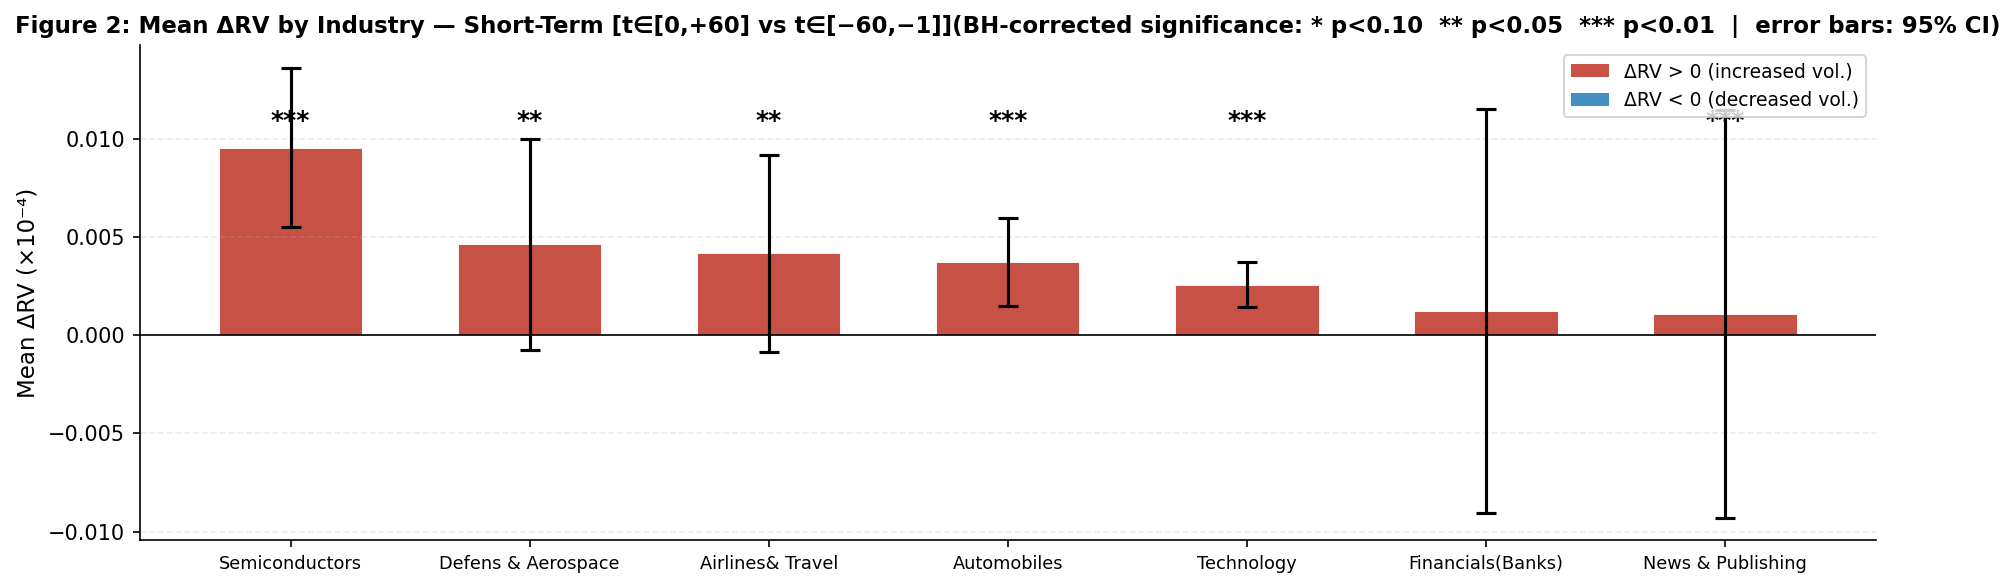

✅ Saved: fig2_mean_drv_sorted_bar.png


4103

In [21]:
plt.close('all'); import gc; gc.collect()

ts2 = test_summary.reset_index().copy()
ts2 = ts2.sort_values('mean_drv', ascending=False).reset_index(drop=True)

ci_lo, ci_hi = [], []
for _, row in ts2.iterrows():
    sub = results[results['industry'] == row['industry']]['drv'].dropna()
    n = len(sub)
    if n > 1:
        se = sub.std(ddof=1) / np.sqrt(n)
        tc = stats.t.ppf(0.975, df=n-1)
        ci_lo.append(sub.mean() - tc*se)
        ci_hi.append(sub.mean() + tc*se)
    else:
        ci_lo.append(np.nan); ci_hi.append(np.nan)
ts2['ci_lo'] = ci_lo
ts2['ci_hi'] = ci_hi

fig, ax = plt.subplots(figsize=(13, 5.5))
bar_colors = ['#c0392b' if v >= 0 else '#2980b9' for v in ts2['mean_drv']]
x = np.arange(len(ts2))

ax.bar(x, ts2['mean_drv'] * 1e4, color=bar_colors,
       width=0.6, alpha=0.88, edgecolor='white', linewidth=0.5)

el_raw = (ts2['mean_drv'] - ts2['ci_lo']).values * 1e4
eu_raw = (ts2['ci_hi']  - ts2['mean_drv']).values * 1e4
el = np.where(np.isnan(el_raw), 0, el_raw)
eu = np.where(np.isnan(eu_raw), 0, eu_raw)
ax.errorbar(x, ts2['mean_drv'] * 1e4, yerr=[el, eu],
            fmt='none', color='black', capsize=5, linewidth=1.5, capthick=1.5)

ymax = (ts2['mean_drv'] * 1e4).max()
for i, (_, row) in enumerate(ts2.iterrows()):
    sig = row.get('sig_bh', row['sig_patell'])
    if sig and sig not in ('n.s.', ''):
        ypos = ymax * 1.08
        ax.text(i, ypos, sig, ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)

# Use short single-line labels with rotation to avoid extra whitespace
short_labels = {
    'Airlines & Travel': 'Airlines& Travel',
    'Automobiles': 'Automobiles',
    'Chemicals': 'Chemicals',
    'Construction': 'Construction',
    'Defense & Aerospace': 'Defens & Aerospace',
    'Financials (Banks)': 'Financials(Banks)',
    'News & Publishing': 'News & Publishing',
    'Oil & Gas': 'Oil & Gas',
    'Semiconductors': 'Semiconductors',
    'Technology': 'Technology',
}
tick_labels = [short_labels.get(r['label'], r['label']) for _, r in ts2.iterrows()]
ax.set_xticklabels(tick_labels, rotation=0, ha='center', fontsize=8.5,
                   linespacing=1.2)

ax.set_ylabel('Mean ΔRV (×10⁻⁴)', fontsize=11)
ax.set_title(
    'Figure 2: Mean ΔRV by Industry — Short-Term [t∈[0,+60] vs t∈[−60,−1]]'
    '(BH-corrected significance: * p<0.10  ** p<0.05  *** p<0.01  |  error bars: 95% CI)',
    fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#c0392b', alpha=0.88, label='ΔRV > 0 (increased vol.)'),
    Patch(facecolor='#2980b9', alpha=0.88, label='ΔRV < 0 (decreased vol.)'),
], loc='upper right', fontsize=9)

plt.tight_layout()
fig.set_size_inches(13, 5)
plt.subplots_adjust(top=0.88, bottom=0.22, left=0.08, right=0.97)
out_path = os.path.join(PLOT_DIR, 'fig2_mean_drv_sorted_bar.png')
plt.savefig(out_path, dpi=150)
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 3: ΔRV Distribution by Industry (Box Plot)

**Goal:** Show the full event-level distribution of $\Delta RV$ per industry.

In [ ]:
plt.close('all'); import gc; gc.collect()

fig, ax = plt.subplots(figsize=(13, 5))
plot_data  = [results[results['industry']==ind]['drv'].dropna().values * 1e4
              for ind in ALL_INDUSTRIES]
short_lbls = [IND_MAP[ind] for ind in ALL_INDUSTRIES]

bp = ax.boxplot(plot_data, labels=short_lbls,
                patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.35),
                boxprops=dict(alpha=0.82),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1))

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)

ax.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.8,
           label='ΔRV = 0 (no effect)')
ax.set_ylabel('ΔRV (×10⁻⁴)', fontsize=11)
ax.set_title(
    'Figure 3: Distribution of ΔRV by Industry — Short-Term\n'
    'Box = IQR, Whiskers = 1.5×IQR, Dots = Outliers',
    fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Clip y-axis to 2nd-98th percentile to suppress extreme outliers
all_drv = np.concatenate([d for d in plot_data if len(d) > 0])
if len(all_drv) > 0:
    ylo, yhi = np.nanpercentile(all_drv, [2, 98])
    pad = (yhi - ylo) * 0.1
    ax.set_ylim(ylo - pad, yhi + pad)

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, 'fig3_boxplot_drv.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 5: Per-Minute AAV_t Heatmap — All Industries × 121 Bars

**Goal:** Colour heatmap of the full 10-industry × 121-bar AAV matrix.
Pinpoints exactly which minute and industry shows the strongest reaction.

In [ ]:
plt.close('all'); import gc; gc.collect()

heatmap_data = aav_df.rename(columns=IND_MAP).T * 1e4   # (10 industries) × (121 bars)

fig, ax = plt.subplots(figsize=(18, 4))
vmax = np.nanpercentile(np.abs(heatmap_data.values), 95)
im   = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r',
                 vmin=-vmax, vmax=vmax)

# x-axis: every 10 minutes
tick_t   = [t for t in T_VALS if t % 10 == 0]
tick_idx = [T_VALS.index(t) for t in tick_t]
ax.set_xticks(tick_idx)
ax.set_xticklabels([f't={t}' for t in tick_t], fontsize=8)

ax.set_yticks(range(len(IND_LABELS)))
ax.set_yticklabels(IND_LABELS, fontsize=8)

# Vertical dividers at t=0
t0_idx = T_VALS.index(0)
ax.axvline(t0_idx - 0.5, color='black', linewidth=2.2, linestyle='-', alpha=0.9)
ax.axvline(t0_idx + 0.5, color='black', linewidth=2.2, linestyle='-', alpha=0.9)

plt.colorbar(im, ax=ax, label='AAV_t (×10⁻⁴)', shrink=0.9)
ax.set_title(
    'Figure 5: Per-Minute AAV_t Heatmap — t=[−60, +60] vs Pre-Event Baseline\n'
    'Red = above baseline | Green = below baseline | Black lines = tweet bar (t=0)',
    fontsize=11, fontweight='bold')

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, 'fig5_heatmap_aav_minute.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Final Summary

In [ ]:
print('=' * 76)
print('  TRUMP TWEET EVENT STUDY — SHORT-TERM MINUTE-LEVEL SUMMARY')
print('=' * 76)
print(f'  Events loaded     : {len(panels)} minute-level panels')
print(f'  Industries        : {N_IND}')
print(f'  Resolution        : 1-minute bars  (t = minute offset from tweet bar)')
print(f'  Pre window        : t=[{PRE_T_START}, {PRE_T_END}]   ({abs(PRE_T_START)} bars)  → RV_pre  = mean(r²)')
print(f'  Post window       : t=[{POST_T_START}, +{POST_T_END}]  ({POST_T_END - POST_T_START + 1} bars)  → RV_post = mean(r²)')
print(f'  Effect measure    : ΔRV = RV_post − RV_pre  (per-bar averages, length-normalized)')
print(f'  Primary test      : Patell (1976) standardized t-test')
print(f'  Robustness        : Wilcoxon, OLS HC3, BH FDR correction')
print('=' * 76)

ts = test_summary.reset_index()
sig_pos = ts[(ts['p_patell'] < 0.10) & (ts['mean_drv'] > 0)]
sig_neg = ts[(ts['p_patell'] < 0.10) & (ts['mean_drv'] < 0)]
nsig    = ts[ts['p_patell'] >= 0.10]

if len(sig_pos) > 0:
    print('\n  📈 SIGNIFICANT POSITIVE ΔRV (tweet INCREASED volatility):')
    for _, r in sig_pos.sort_values('mean_drv', ascending=False).iterrows():
        print(f"     {r['label']:<30}  ΔRV={r['mean_drv']*1e4:.4f}×10⁻⁴  "
              f"N={int(r['n_events'])}  t={r['t_patell']:.2f}  "
              f"p={r['p_patell']:.4f} {r['sig_patell']}")

if len(sig_neg) > 0:
    print('\n  📉 SIGNIFICANT NEGATIVE ΔRV (tweet DECREASED volatility):')
    for _, r in sig_neg.sort_values('mean_drv').iterrows():
        print(f"     {r['label']:<30}  ΔRV={r['mean_drv']*1e4:.4f}×10⁻⁴  "
              f"N={int(r['n_events'])}  t={r['t_patell']:.2f}  "
              f"p={r['p_patell']:.4f} {r['sig_patell']}")

if len(nsig) > 0:
    print('\n  ➖ NO SIGNIFICANT EFFECT:')
    for _, r in nsig.iterrows():
        print(f"     {r['label']:<30}  N={int(r['n_events'])}  "
              f"p={r['p_patell']:.4f}  n.s.")

print('\n  Significance: * p<0.10  ** p<0.05  *** p<0.01 (two-tailed, Patell)')
print('=' * 76)


---
## Appendix: Methodological Notes

### Core Formula

$$RV_{pre}  = \frac{1}{60}\sum_{m=-60}^{-1} r_m^2 \qquad
RV_{post} = \frac{1}{61}\sum_{m=\;0}^{+60} r_m^2 \qquad
\Delta RV = RV_{post} - RV_{pre}$$

Both windows use **per-bar averages** (divided by window length). This normalizes
the asymmetric window sizes (pre=60 bars, post=61 bars), ensuring $\Delta RV$
reflects the per-minute change in realized variance — not an artifact of bar count.

### AAV Per-Bar Baseline

$$AAV_t^{(ind)} = \frac{1}{N_{ind}} \sum_{e=1}^{N_{ind}}
\left(r_{e,t}^2 - RV_{pre,e}\right)$$

where $RV_{pre,e} = \text{mean}(r_t^2,\; t \in [-60,-1])$ — the same per-bar
baseline used in $\Delta RV$.

### Design Rationale
- **Per-bar average:** Dividing by window length normalizes for the 60 vs 61 bar
  asymmetry (pre excludes t=0; post includes t=0). Ensures $\Delta RV > 0$ truly
  reflects higher per-minute variance post-tweet, not just more bars.
- **Minute resolution:** 1-minute bars reveal the exact timing of the volatility
  response — whether concentrated at t=0 or sustained over the hour.
- **AAV baseline consistency:** The same $RV_{pre}$ (per-bar mean) is used as the
  reference in both $\Delta RV$ and the per-bar $AAV_t$ series.

### t=0 Assignment
| Scenario | Assignment |
|---|---|
| Tweet during 09:30–16:00 ET on weekday | 1-minute bar containing tweet |
| Tweet after 16:00 ET | Next trading day 09:30 ET open bar |
| Tweet before 09:30 ET | Same-day 09:30 ET open bar |
| Tweet on weekend or holiday | Next trading day 09:30 ET |

### Patell Standardization
$$\hat{\Delta RV}_e = \frac{\Delta RV_e}{\sigma(r_t^2,\; t \in [-60,-1])}$$

Standardization by cross-bar std of pre-window $r_t^2$ corrects for
heteroskedasticity across events.